<a href="https://colab.research.google.com/github/AmnaNoorr/Machine-Learning-Data-Analyst---Agribusiness/blob/main/Data_Collection_and_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 1

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhinav0711/crop-yeild-prediction")

print("Path to dataset files:", path)

100%|██████████| 4.85k/4.85k [00:00<00:00, 8.88MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abhinav0711/crop-yeild-prediction/versions/1


In [4]:
# Cell 1: Load and Inspect
import os
import kagglehub
import pandas as pd
import numpy as np

# 1. Download dataset via kagglehub
path = kagglehub.dataset_download("abhinav0711/crop-yeild-prediction")
print("Dataset downloaded to path:", path)

# 2. Find and load the CSV file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
full_path = os.path.join(path, csv_files[0])
df_raw = pd.read_csv(full_path)

print(f"\nSuccessfully loaded: {csv_files[0]}")
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns\n")
print("--- Column Summary & Missing Values ---")
print(df_raw.info())
print("\nMissing values count per column:")
print(df_raw.isnull().sum())
df_raw.head()

Using Colab cache for faster access to the 'crop-yeild-prediction' dataset.
Dataset downloaded to path: /kaggle/input/crop-yeild-prediction

Successfully loaded: crop_yield_fertilizer_300.csv
Dataset Shape: 300 rows, 9 columns

--- Column Summary & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                300 non-null    int64  
 1   Crop              300 non-null    object 
 2   Temperature (°C)  300 non-null    float64
 3   Rainfall (mm)     300 non-null    int64  
 4   Soil pH           300 non-null    float64
 5   Nitrogen (N)      300 non-null    int64  
 6   Phosphorus (P)    300 non-null    int64  
 7   Potassium (K)     300 non-null    int64  
 8   Yield (tons/ha)   300 non-null    float64
dtypes: float64(3), int64(5), object(1)
memory usage: 21.2+ KB
None

Missing values count per column:
ID       

,ID,Crop,Temperature (°C),Rainfall (mm),Soil pH,Nitrogen (N),Phosphorus (P),Potassium (K),Yield (tons/ha)
0,1,Maize,26.2,1218,5.9,59,67,34,6.27
1,2,Rice,27.6,1338,5.5,63,56,16,6.30
2,3,Wheat,24.5,599,6.0,62,50,55,2.78
3,4,Sugarcane,34.6,1274,6.5,33,68,17,1.94
4,5,Cotton,18.8,1196,6.0,43,33,32,4.46


In [5]:
# Cell 2: Deduplication & Text Cleaning
df_clean = df_raw.copy()

# 1. Remove Exact Duplicates
initial_rows = len(df_clean)
df_clean.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - len(df_clean)
print(f"Duplicates found and removed: {duplicates_removed}")

# 2. Standardize Text Formatting (strip whitespace and unify casing)
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

print(f"Current shape after deduplication: {df_clean.shape}")

Duplicates found and removed: 0
Current shape after deduplication: (300, 9)


In [6]:
# Cell 3: Missing Value Imputation
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns

missing_summary = {}

# Impute numerical features using Median
for col in numerical_cols:
    null_count = df_clean[col].isnull().sum()
    if null_count > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        missing_summary[col] = f"Imputed {null_count} missing values with Median ({median_val:.2f})"

# Impute categorical features using Mode
for col in categorical_cols:
    null_count = df_clean[col].isnull().sum()
    if null_count > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        missing_summary[col] = f"Imputed {null_count} missing values with Mode ('{mode_val}')"

if not missing_summary:
    print("No missing values found in the dataset! Step skipped cleanly.")
else:
    for k, v in missing_summary.items():
        print(f"- {k}: {v}")

print("Remaining missing values:", df_clean.isnull().sum().sum())

No missing values found in the dataset! Step skipped cleanly.
Remaining missing values: 0


In [7]:
# Cell 4: Outlier Handling
outlier_report = {}

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outlier_report[col] = outliers_count

    # Cap (Winsorize) extreme values
    df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])
    df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])

print("--- Outlier Detection & Capping Report (IQR Method) ---")
for col, count in outlier_report.items():
    print(f"Column '{col}': {count} extreme values capped to IQR bounds.")

--- Outlier Detection & Capping Report (IQR Method) ---
Column 'ID': 0 extreme values capped to IQR bounds.
Column 'Temperature (°C)': 0 extreme values capped to IQR bounds.
Column 'Rainfall (mm)': 0 extreme values capped to IQR bounds.
Column 'Soil pH': 0 extreme values capped to IQR bounds.
Column 'Nitrogen (N)': 0 extreme values capped to IQR bounds.
Column 'Phosphorus (P)': 0 extreme values capped to IQR bounds.
Column 'Potassium (K)': 0 extreme values capped to IQR bounds.
Column 'Yield (tons/ha)': 0 extreme values capped to IQR bounds.


In [8]:
# Cell 5: Normalization & Statistical Summary
from sklearn.preprocessing import MinMaxScaler

df_normalized = df_clean.copy()

# Target columns (like Yield) can be preserved or scaled separately
scaler = MinMaxScaler()
df_normalized[numerical_cols] = scaler.fit_transform(df_clean[numerical_cols])

# Generate descriptive statistical tables
raw_stats = df_raw.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2)
clean_stats = df_clean.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2)
norm_stats = df_normalized.describe().T[['mean', 'std', 'min', '50%', 'max']].round(2)

print("--- Cleaned Statistical Summary ---")
print(clean_stats)

--- Cleaned Statistical Summary ---
                     mean     std     min      50%     max
ID                 150.50   86.75    1.00   150.50   300.0
Temperature (°C)    24.71    5.80   15.10    24.30    35.0
Rainfall (mm)     1179.64  455.80  407.00  1204.50  1998.0
Soil pH              6.45    0.57    5.50     6.40     7.5
Nitrogen (N)        53.86   14.56   30.00    54.00    80.0
Phosphorus (P)      45.44   14.44   20.00    46.00    70.0
Potassium (K)       38.61   13.69   15.00    39.00    60.0
Yield (tons/ha)      4.11    1.65    1.52     4.09     7.0


Week2

In [11]:
# Cell 1: Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 1.0

# Load Week 1 cleaned dataset
df = pd.read_csv("cleaned_crop_yield_data.csv")
print("Cleaned Dataset Loaded Successfully!")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Cleaned Dataset Loaded Successfully!
Dataset Dimensions: 300 rows, 9 columns



,ID,Crop,Temperature (°C),Rainfall (mm),Soil pH,Nitrogen (N),Phosphorus (P),Potassium (K),Yield (tons/ha)
0,0.000000,Maize,0.557789,0.509742,0.20,0.58,0.94,0.422222,0.866788
1,0.003344,Rice,0.628141,0.585167,0.00,0.66,0.72,0.022222,0.872263
2,0.006689,Wheat,0.472362,0.120679,0.25,0.64,0.60,0.888889,0.229927
3,0.010033,Sugarcane,0.979899,0.544940,0.50,0.06,0.96,0.044444,0.076642
4,0.013378,Cotton,0.185930,0.495915,0.25,0.26,0.26,0.377778,0.536496


--- STATISTICAL DISTRIBUTION METRICS ---
                   Mean  Median  Std Dev  Skewness  Kurtosis
ID                0.500   0.500    0.290     0.000    -1.200
Temperature (°C)  0.483   0.462    0.291     0.099    -1.162
Rainfall (mm)     0.486   0.501    0.286     0.064    -1.099
Soil pH           0.477   0.450    0.285     0.119    -1.136
Nitrogen (N)      0.477   0.480    0.291    -0.006    -1.162
Phosphorus (P)    0.509   0.520    0.289    -0.017    -1.140
Potassium (K)     0.525   0.533    0.304    -0.080    -1.272
Yield (tons/ha)   0.473   0.469    0.301     0.086    -1.295


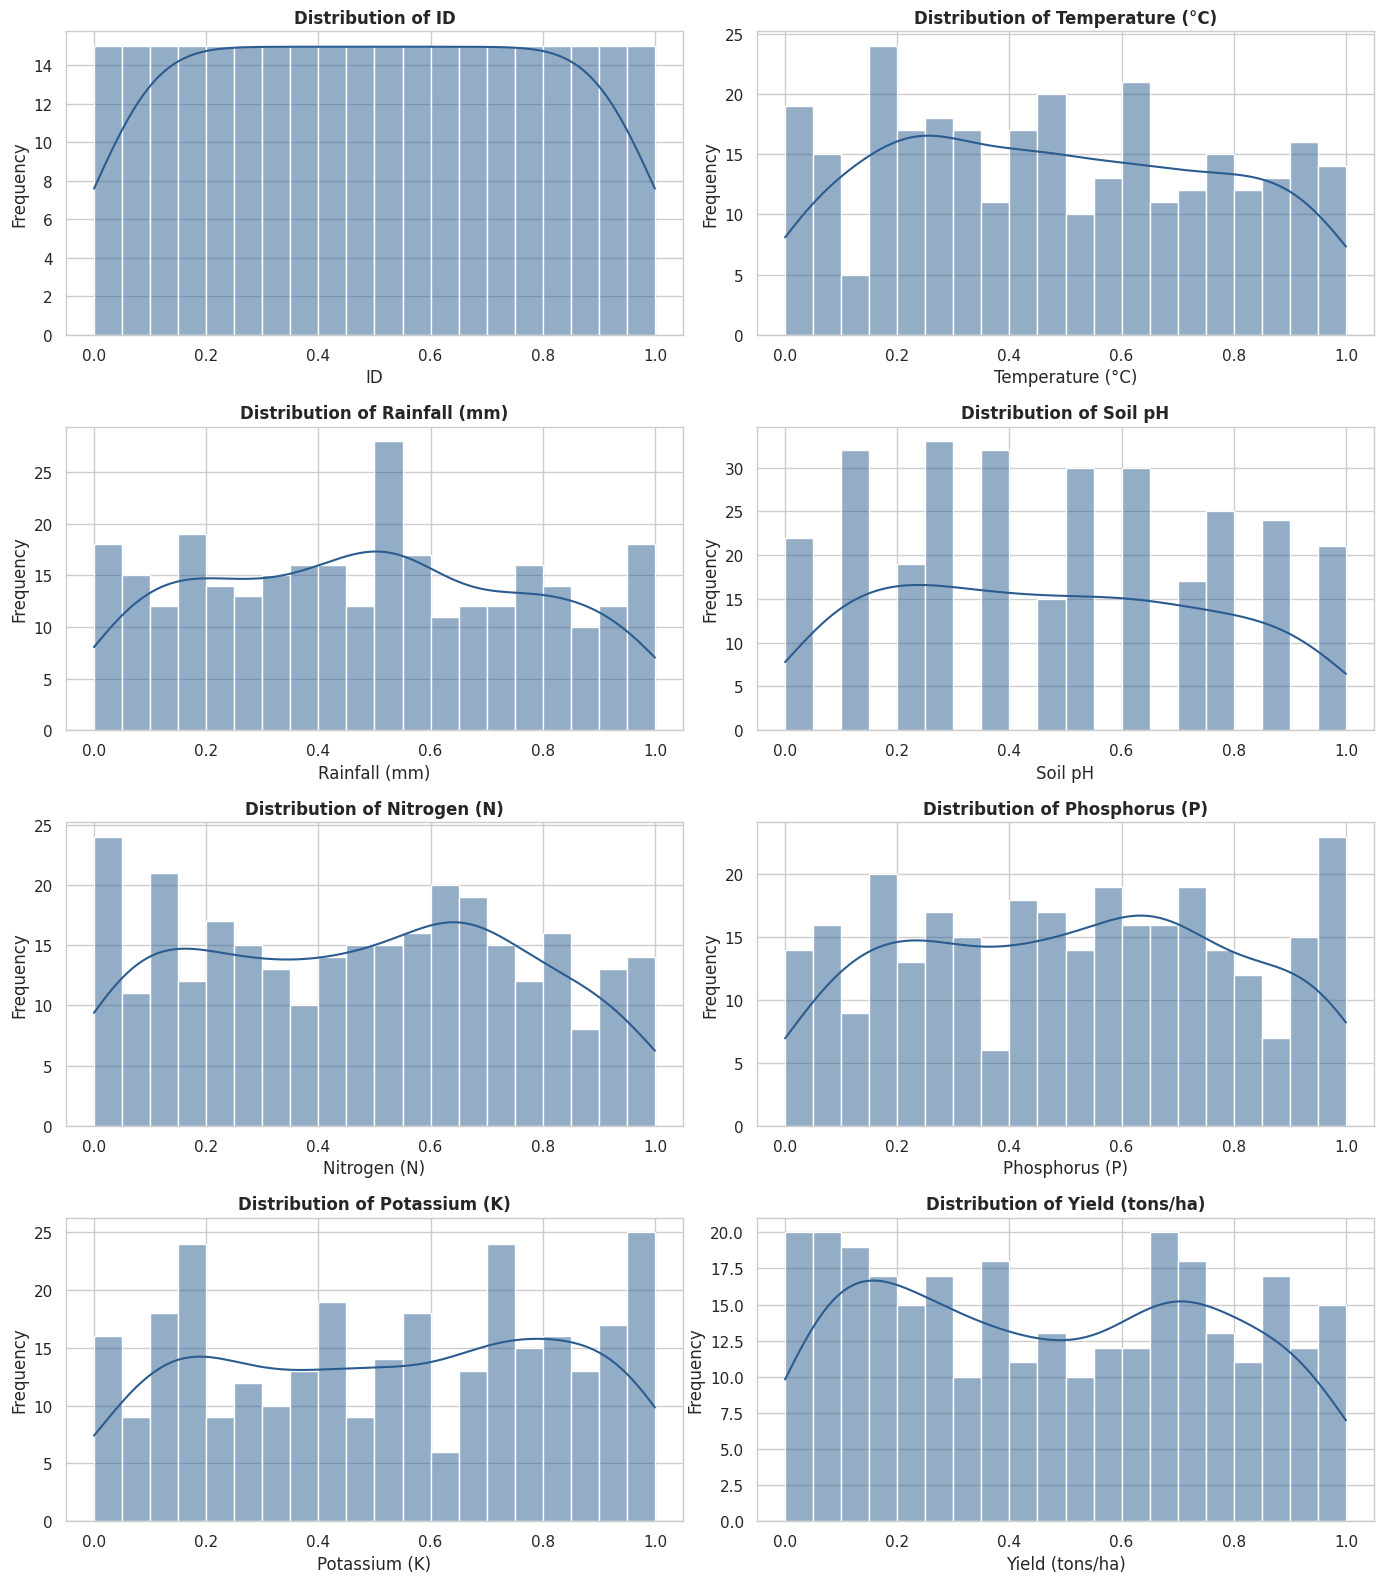

In [12]:
# Cell 2: Feature Distributions
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Summary metrics table (Skewness & Kurtosis)
eda_stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Std Dev': df[numeric_cols].std(),
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurt()
}).round(3)

print("--- STATISTICAL DISTRIBUTION METRICS ---")
print(eda_stats)

# Plot feature distributions
fig, axes = plt.subplots(nrows=(len(numeric_cols) + 1) // 2, ncols=2, figsize=(14, 4 * ((len(numeric_cols) + 1) // 2)))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color="#2b5c8f", bins=20)
    axes[idx].set_title(f"Distribution of {col}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frequency")

# Hide extra subplots if odd number of columns
for i in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=300)
plt.show()

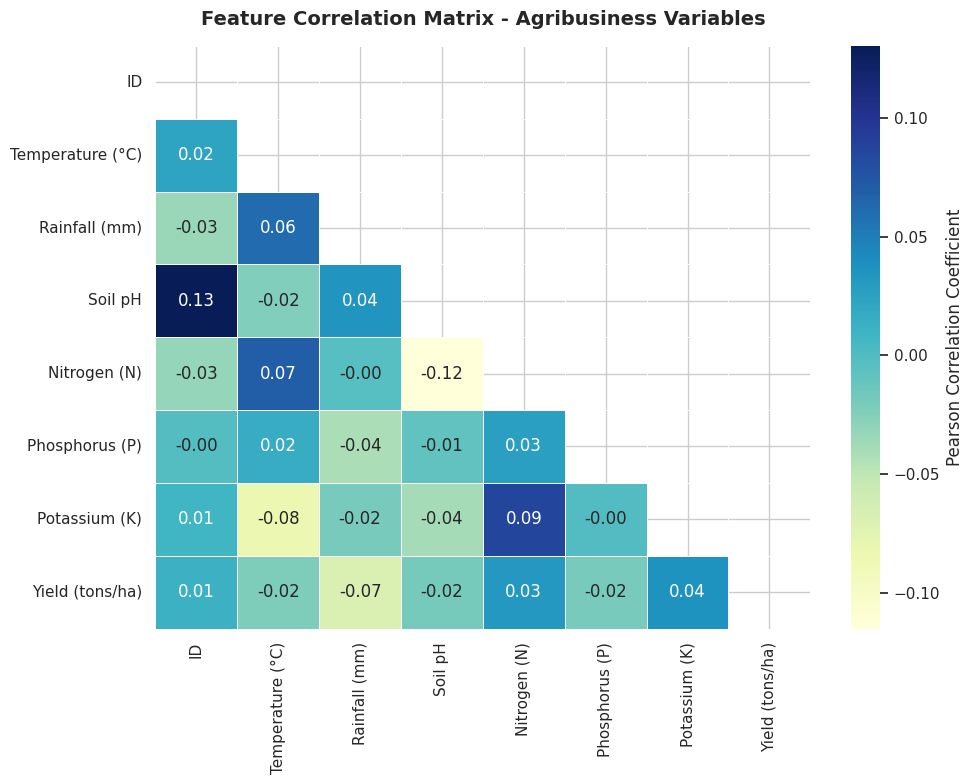

--- Top Feature Correlations with Target (Yield (tons/ha)) ---
Yield (tons/ha)     1.000000
Potassium (K)       0.037276
Nitrogen (N)        0.032106
ID                  0.012313
Soil pH            -0.018363
Phosphorus (P)     -0.019384
Temperature (°C)   -0.022669
Rainfall (mm)      -0.068791
Name: Yield (tons/ha), dtype: float64


In [13]:
# Cell 3: Feature Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()

# Mask upper triangle for cleaner layout
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Pearson Correlation Coefficient'},
    linewidths=0.5
)

plt.title("Feature Correlation Matrix - Agribusiness Variables", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

# Print top correlations relative to target (assuming 'Yield' or last column)
target_col = numeric_cols[-1]
print(f"--- Top Feature Correlations with Target ({target_col}) ---")
print(corr_matrix[target_col].sort_values(ascending=False))

/tmp/ipykernel_676/682869288.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y=target_col, data=df, palette="Set2")


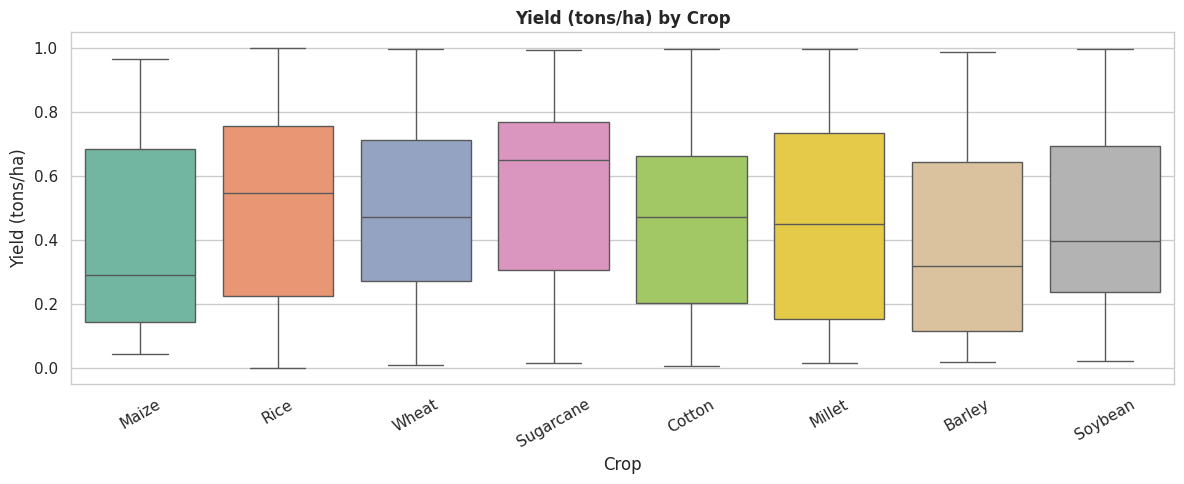

In [14]:
# Cell 4: Categorical Breakdown & Scatter Plots
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    plt.figure(figsize=(12, 5))
    for i, cat in enumerate(categorical_cols[:2]):
        plt.subplot(1, len(categorical_cols[:2]), i+1)
        sns.boxplot(x=cat, y=target_col, data=df, palette="Set2")
        plt.title(f"{target_col} by {cat}", fontsize=12, fontweight='bold')
        plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("categorical_yield_boxplots.png", dpi=300)
    plt.show()
else:
    # Key Scatter Plot between highest correlated feature and target
    top_feature = corr_matrix[target_col].abs().sort_values(ascending=False).index[1]
    plt.figure(figsize=(8, 6))
    sns.regplot(x=top_feature, y=target_col, data=df, scatter_kws={'alpha':0.5, 'color':'#1f77b4'}, line_kws={'color':'red'})
    plt.title(f"Relationship: {top_feature} vs {target_col}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig("scatter_top_feature.png", dpi=300)
    plt.show()